# EPS 109 "Computer Simulations in Earth and Planetary Science"
### Instructor: Burkhard Militzer
### Combined lab and homework assignment on sound and audio files: Part 4


From bCourses, download three files: "audio_file_A.wav", "audio_file_A_SID.wav", and "audio_file_C_SID.wav". You need ot replace SID by your student ID number. 

(1) Execute the following commands at the beginning of for this and all following parts. 

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
import simpleaudio as sa
from scipy.io import wavfile

def PrintArrayInfo(a,name=''):
    if (len(name)==0):
        print("Array info:")
    else:
        print("Array:", name)
    print("shape:", a.shape)
    print("dtype:", a.dtype)
    print("min, max:", a.min(), a.max())
    print()

(2) Play back this WAV file:

In [3]:
filename = 'audio_file_A.wav'
wave_obj = sa.WaveObject.from_wave_file(filename)
#play_obj = wave_obj.play()
#play_obj.wait_done()  # Wait until sound has finished playing

(3) Load and plot the audio information:

Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (88200,)
dtype: int16
min, max: -32767 32767



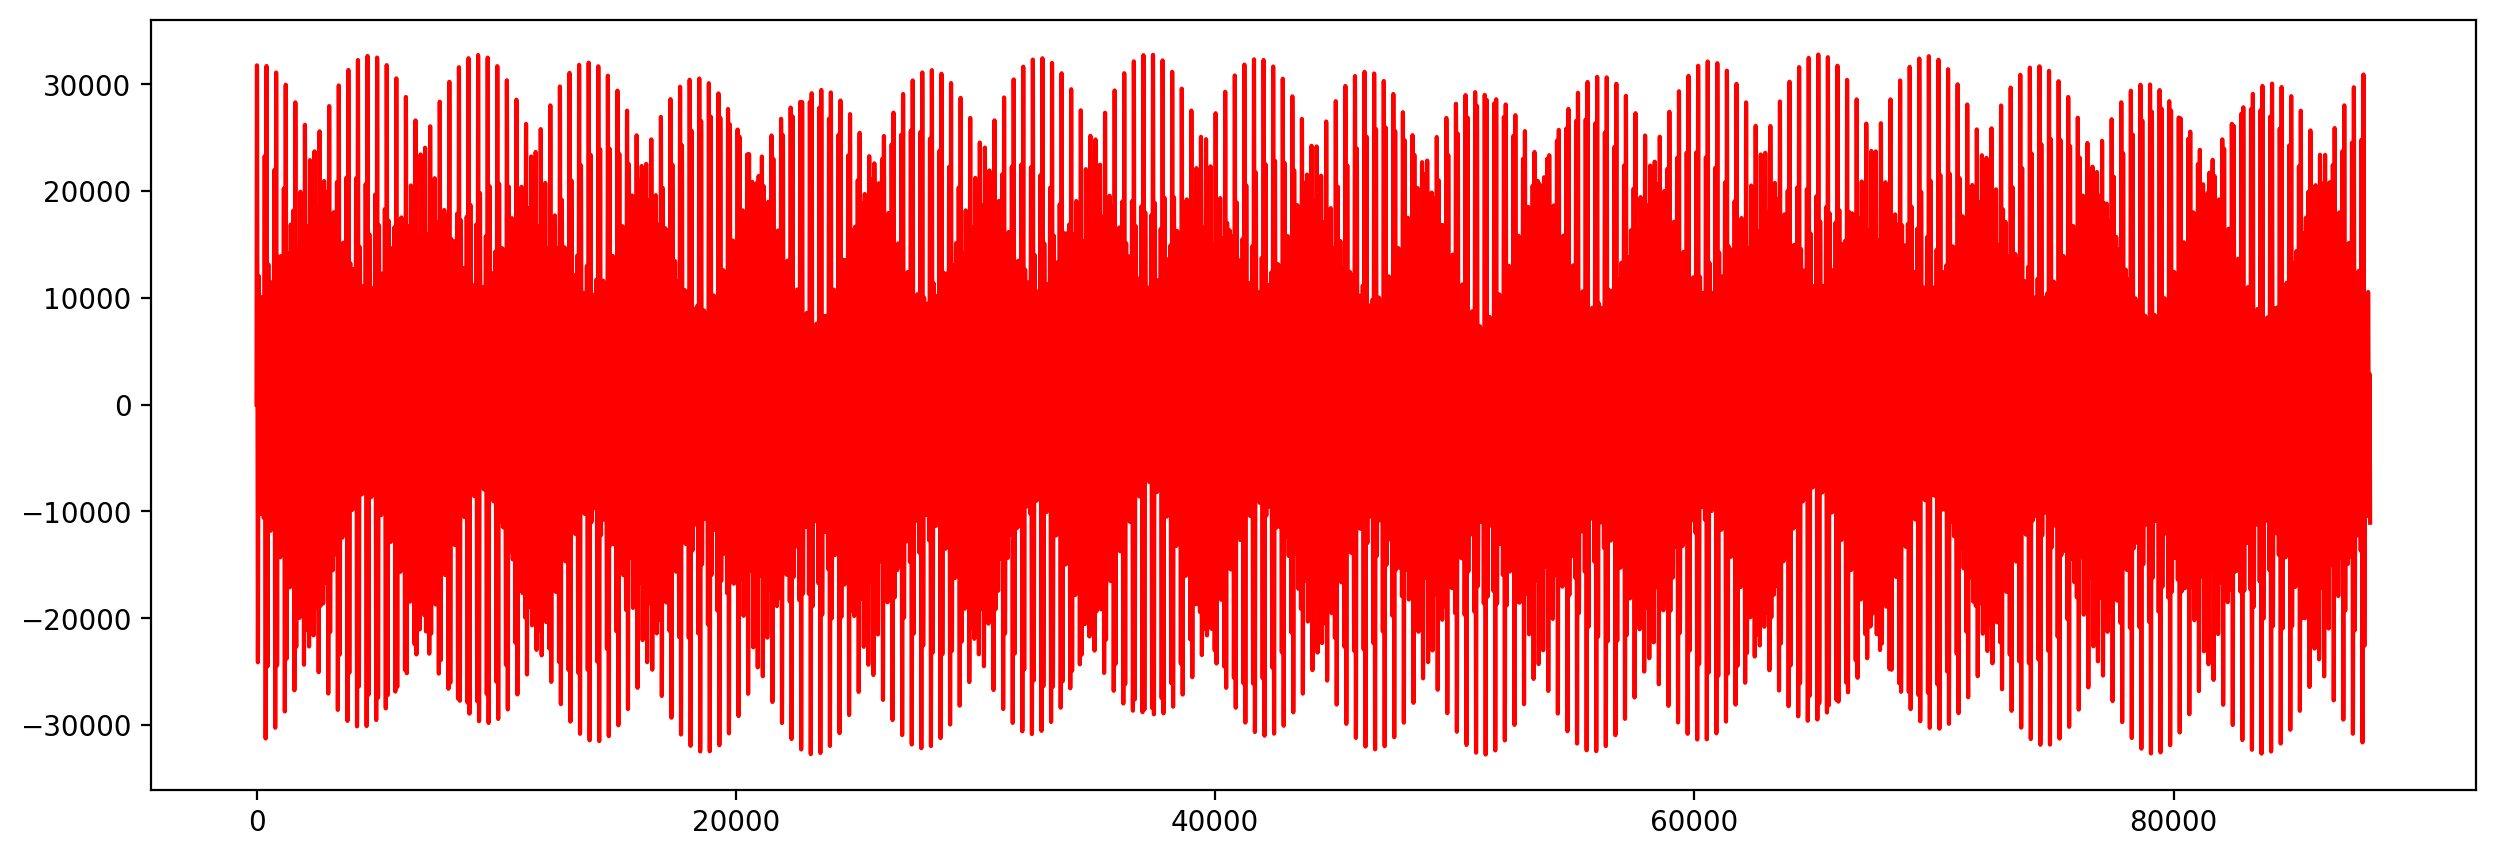

In [4]:
rate, data = wavfile.read(filename)
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()

(4) Zoom in and plot only the first 5000 data points.

Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (88200,)
dtype: int16
min, max: -32767 32767



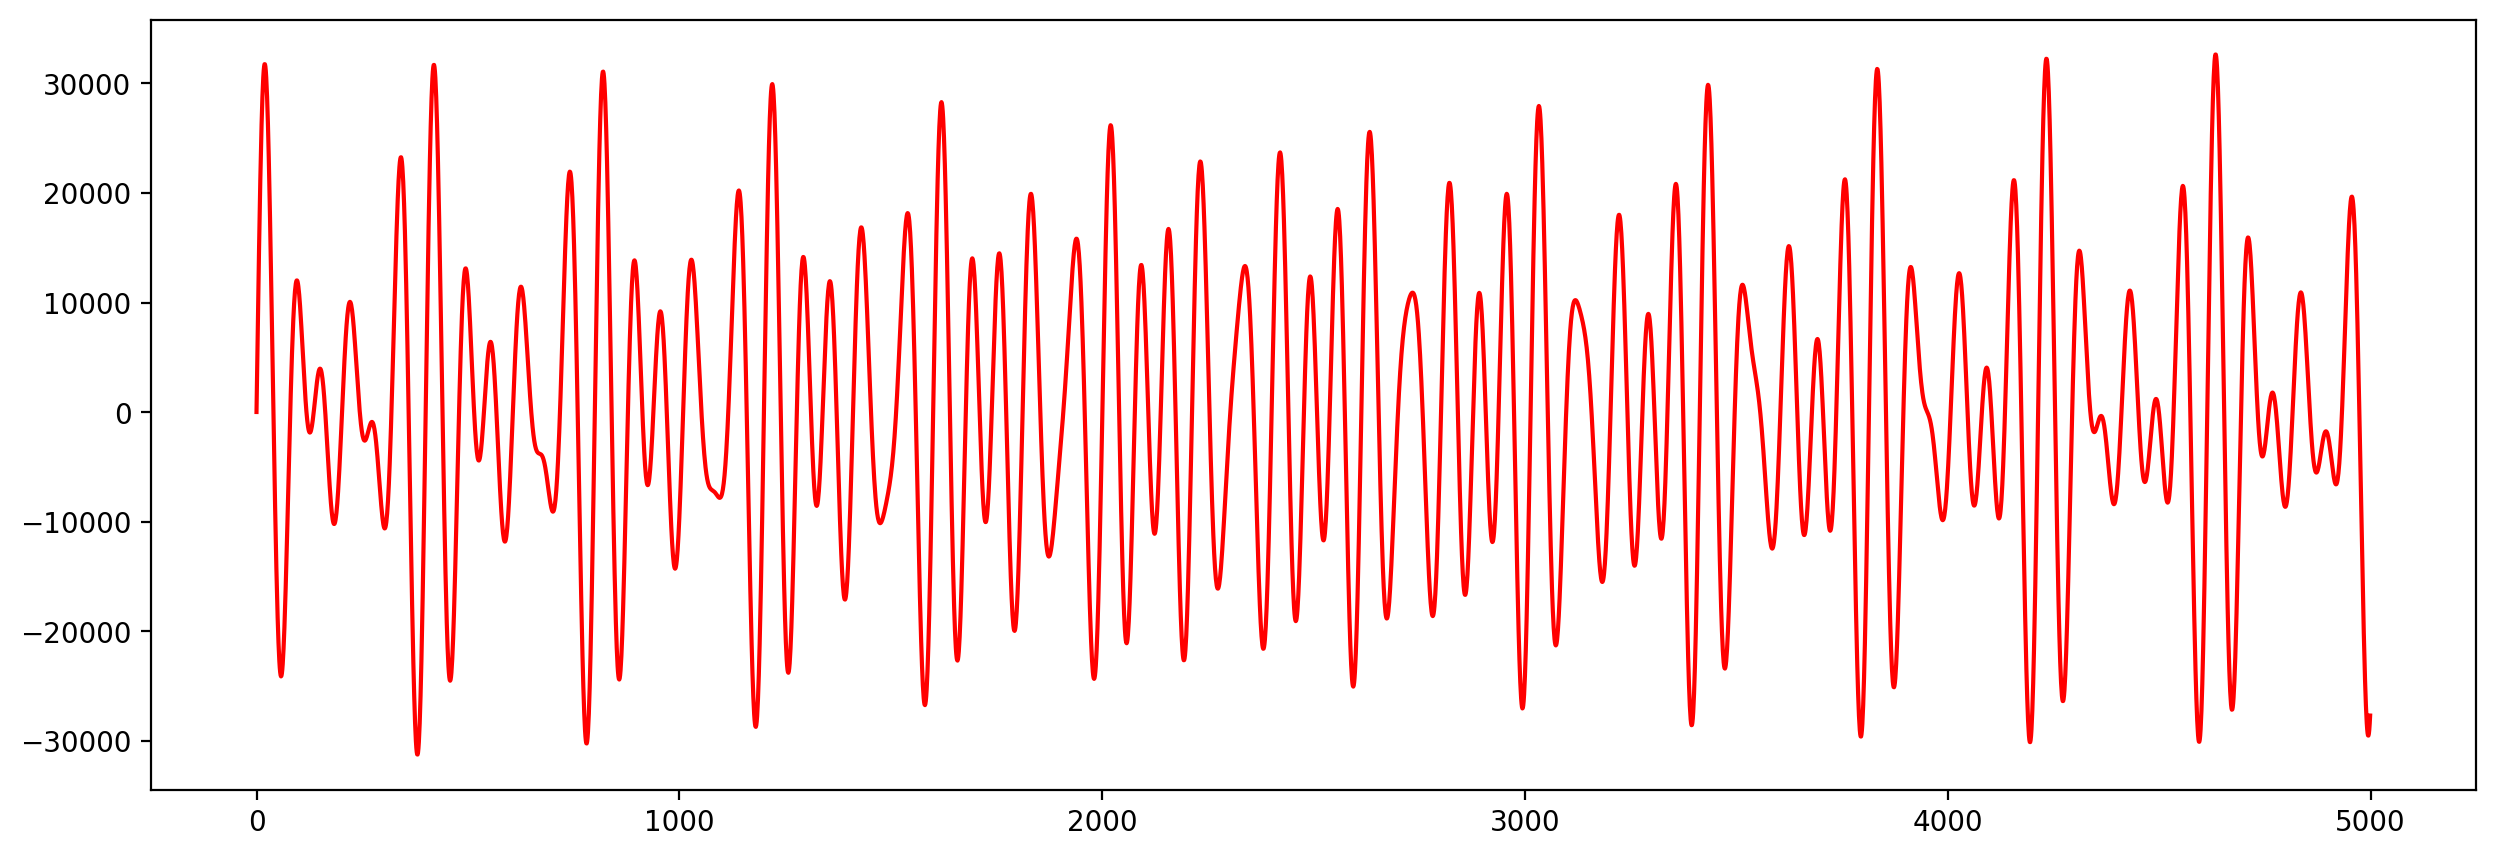

In [5]:
rate, data = wavfile.read(filename)
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data[0:5000],'r-')
plt.show()

There are clearly a number of frequencies hidden in this file. You can hear several of them. Now we want to use discrete Fourier transforms to identify those frequencies $\nu$. 
$$ f^{(sin)}(\nu) = \int_{-\infty}^{+\infty} dt\, x(t)\, \sin(2 \pi \nu t) {\rm ~~~~~~~~and~~~~~~~~}
f^{(cos)}(\nu) = \int_{-\infty}^{+\infty} dt\, x(t)\, \cos(2 \pi \nu t) \,.$$

Instead of continuous function, $f(t)$, our audio signal is provides as a series discrete points $x_{j=0 \ldots n-1}$. $n$ is the number of data points. So our sine and cosine transform assume the following discrete forms:

$$ f^{(sin)}_k = \sum_{j=0}^{n-1} x_j\,\sin \left\{2 \pi \frac{j k}{n} \right\} {\rm ~~~~~~~~~and~~~~~~~~~}
f^{(cos)}_k = \sum_{j=0}^{n-1} x_j\,\cos \left\{2 \pi \frac{j k}{n} \right\}
$$

On a sheet of paper, work out how you convert between time $t$ and index $j$. More importantly work ot the conversion from frequency index $k$ to frequency $\nu$.

(5) Write a Python function that computes $  \left[ f^{(sin)}_k \right]^2 +  \left[ f^{(cos)}_k \right]^2 $ for an arbitrary data set and frequency index $k$.

In [6]:
def fourier(x,k):
    n = len(x)
    j = np.arange(0,n)

    f_sin = np.sum(x * np.sin(2 * np.pi * j * k/n))
    f_cos = np.sum(x * np.cos(2 * np.pi * j * k/n))

    return f_sin**2 + f_cos**2

(6) Construct a array of frequency indicies from 800 and 1600 and call this function for every single one. Plot the result as function of frequency index.

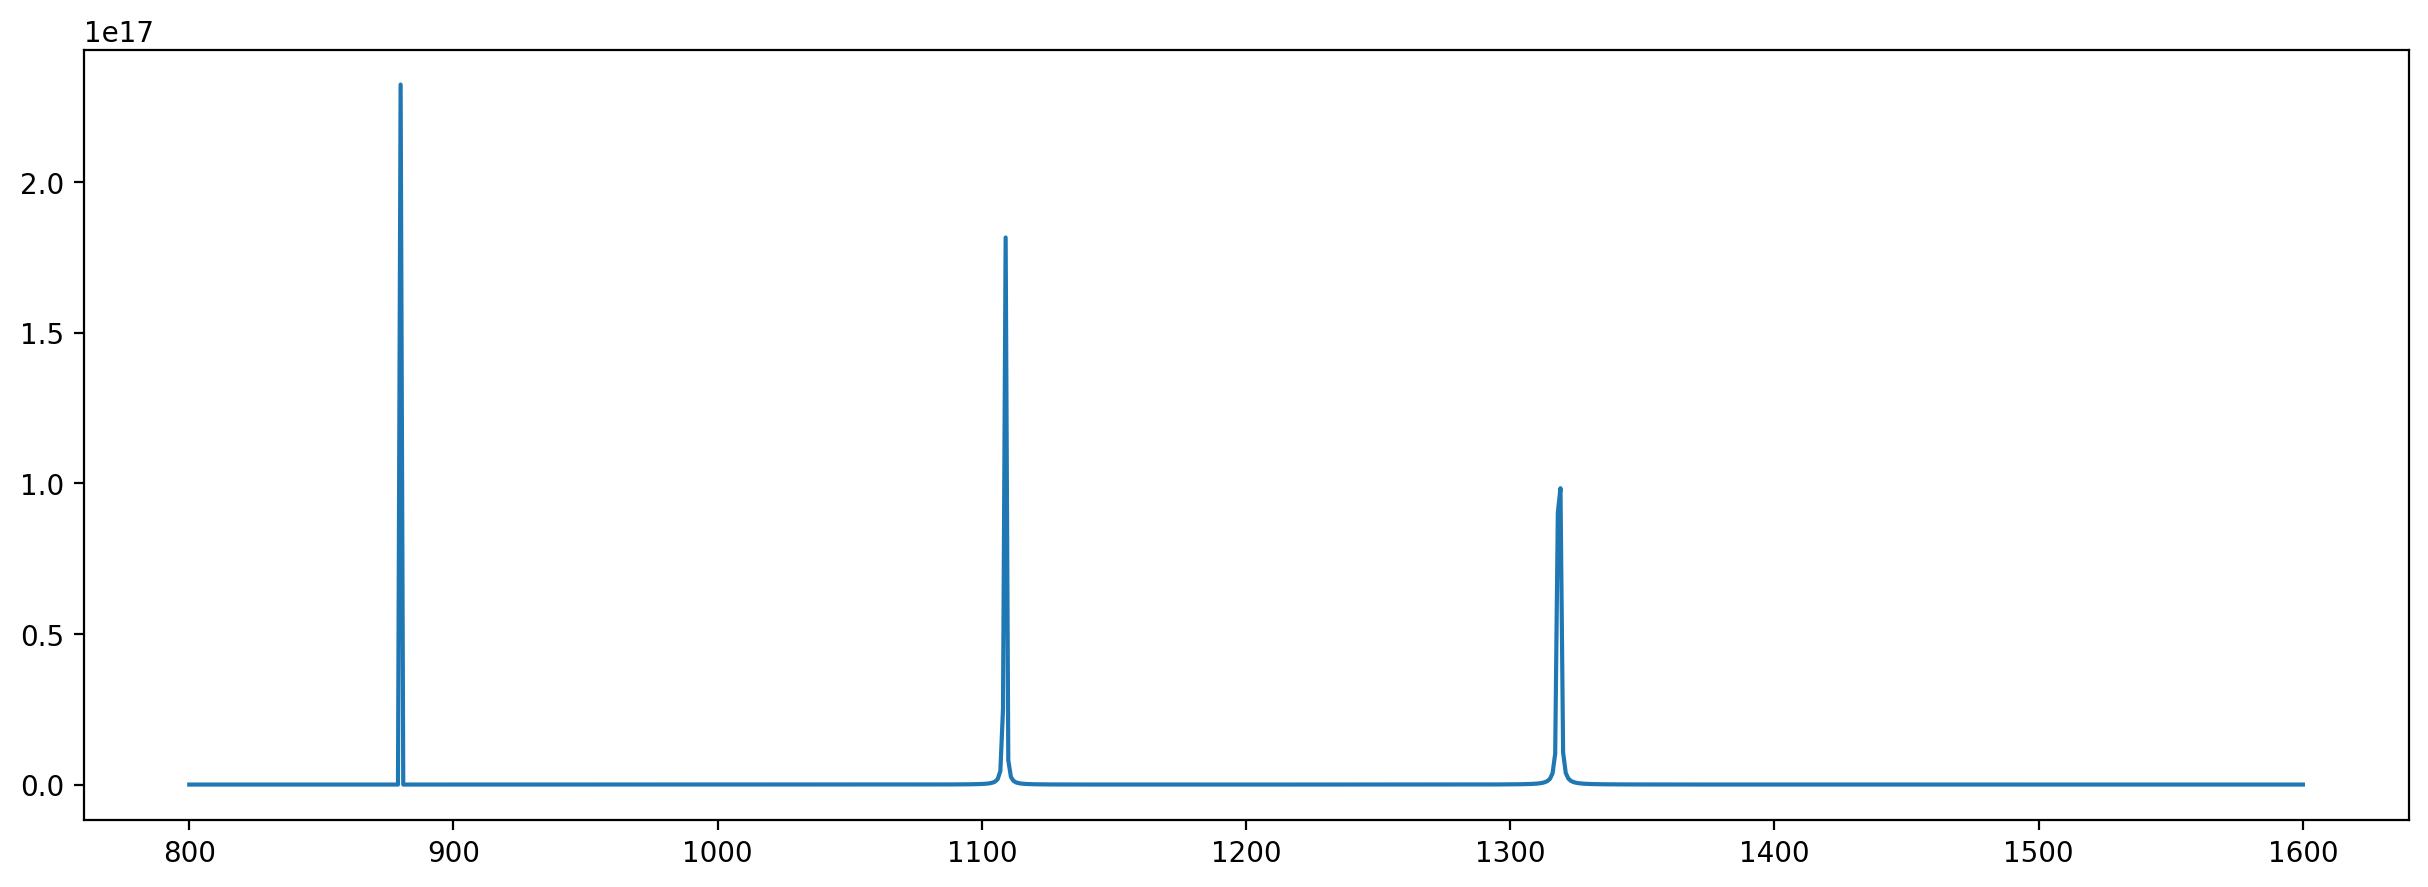

In [10]:
k1 = 800
k2 = 1600
frequency_indices = np.arange(800,1601)
frequency_indices_results = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_indices,frequency_indices_results)

(7) Now plot the same results as function of frequency in units of Hertz. What was the frequency of the wave have that you saw in the previous plot? 

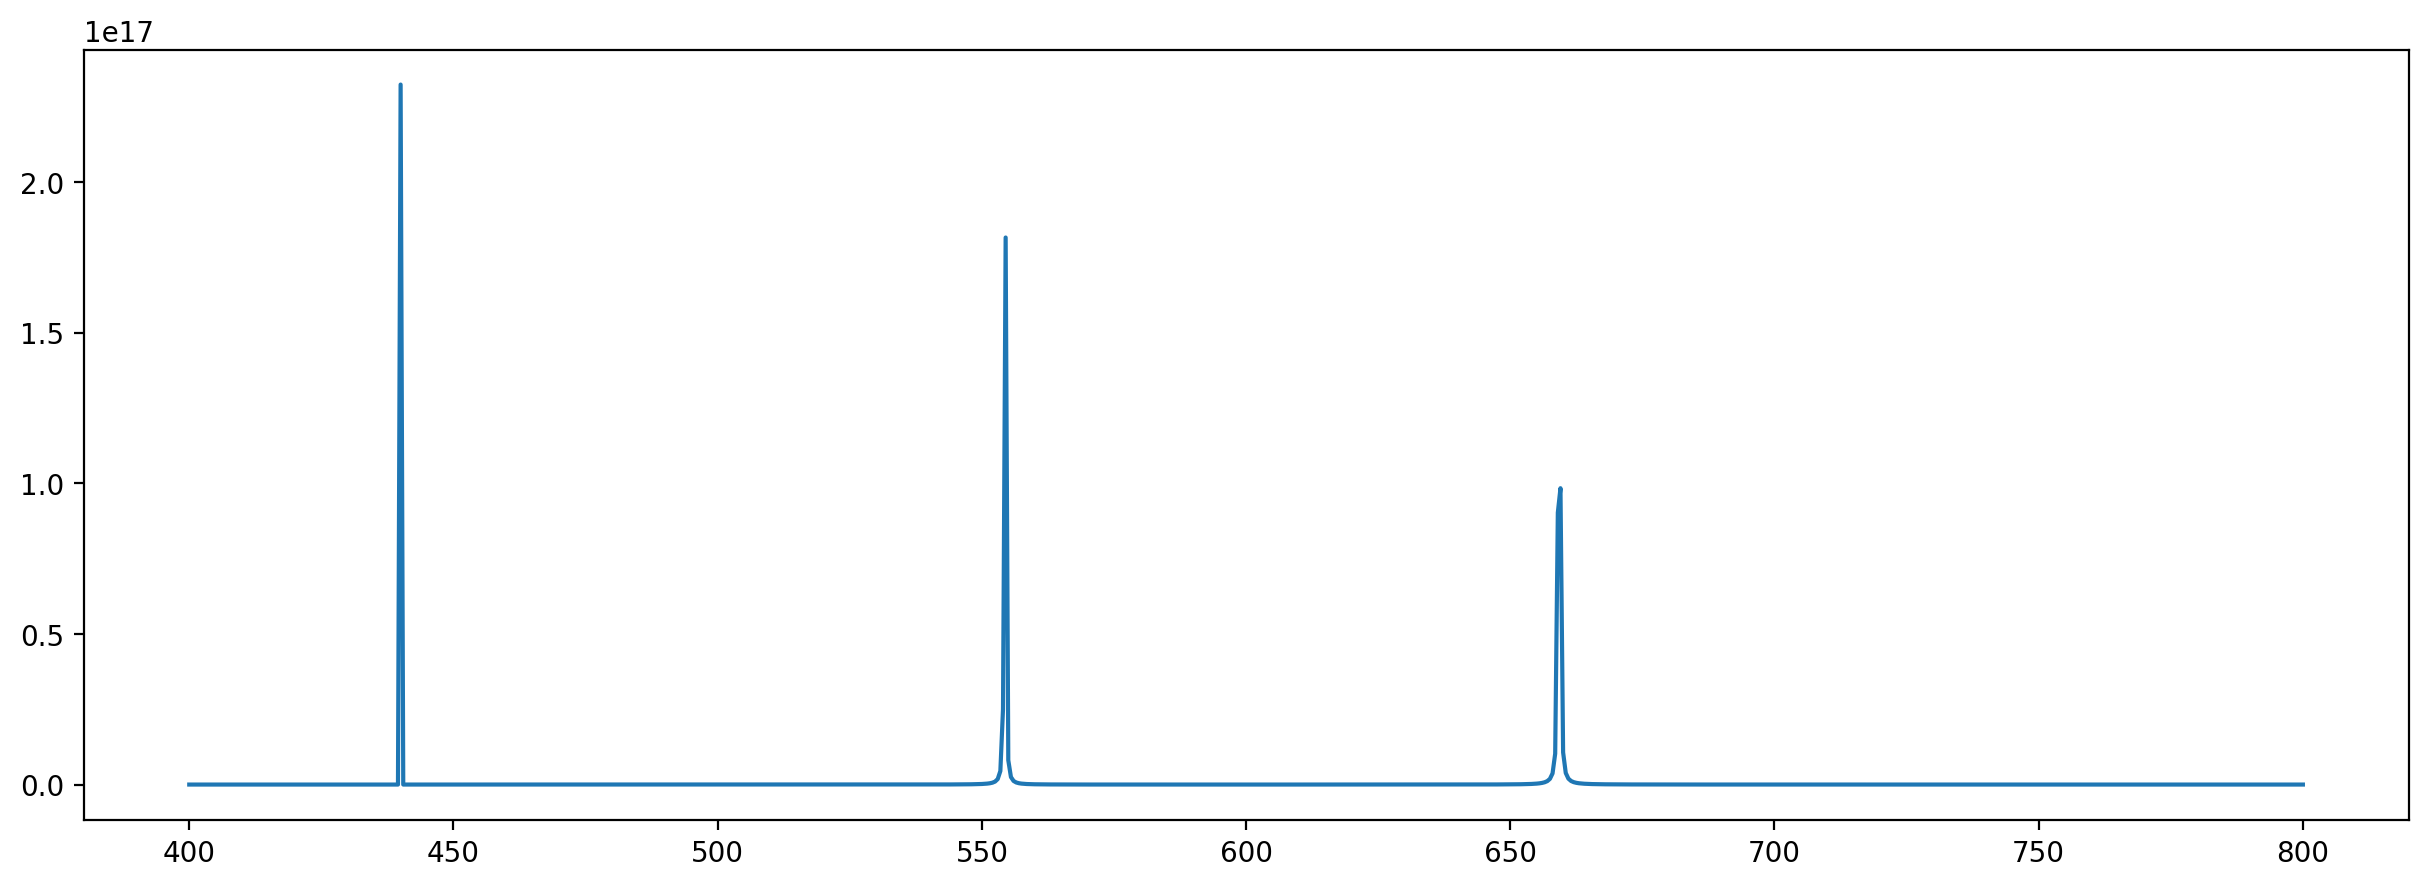

In [12]:
k1 = 800
k2 = 1600
frequency_indices = np.arange(800,1601)
frequency_hz = frequency_indices*(rate/len(data))
frequency_indices_results_hz = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_hz,frequency_indices_results_hz)

In [32]:
peak_indices = np.argsort(frequency_indices_results_hz)[-3:]
peak_frequencies = frequency_hz[peak_indices]
print(peak_frequencies)

[659.5 554.5 440. ]


In [33]:
#There appears to be three frequencies in plot, one at 440 hz, one at 554.5 hz, and one at 659.5 hz.

(8) Finally we want to speed this calculations by using use fast Fourier transform (FFT) routines that are provided in the NumyPy library. Execute the following lines and see what happens. Compare the two resulting plots with your own diagrams above.

[1246143.          +0.j          393505.51136061+192.12014047j
  393589.53810354+140.77714132j ...  393298.62447869+209.78242778j
  393589.53810353-140.77714132j  393505.51136061-192.12014047j]
(88200,)


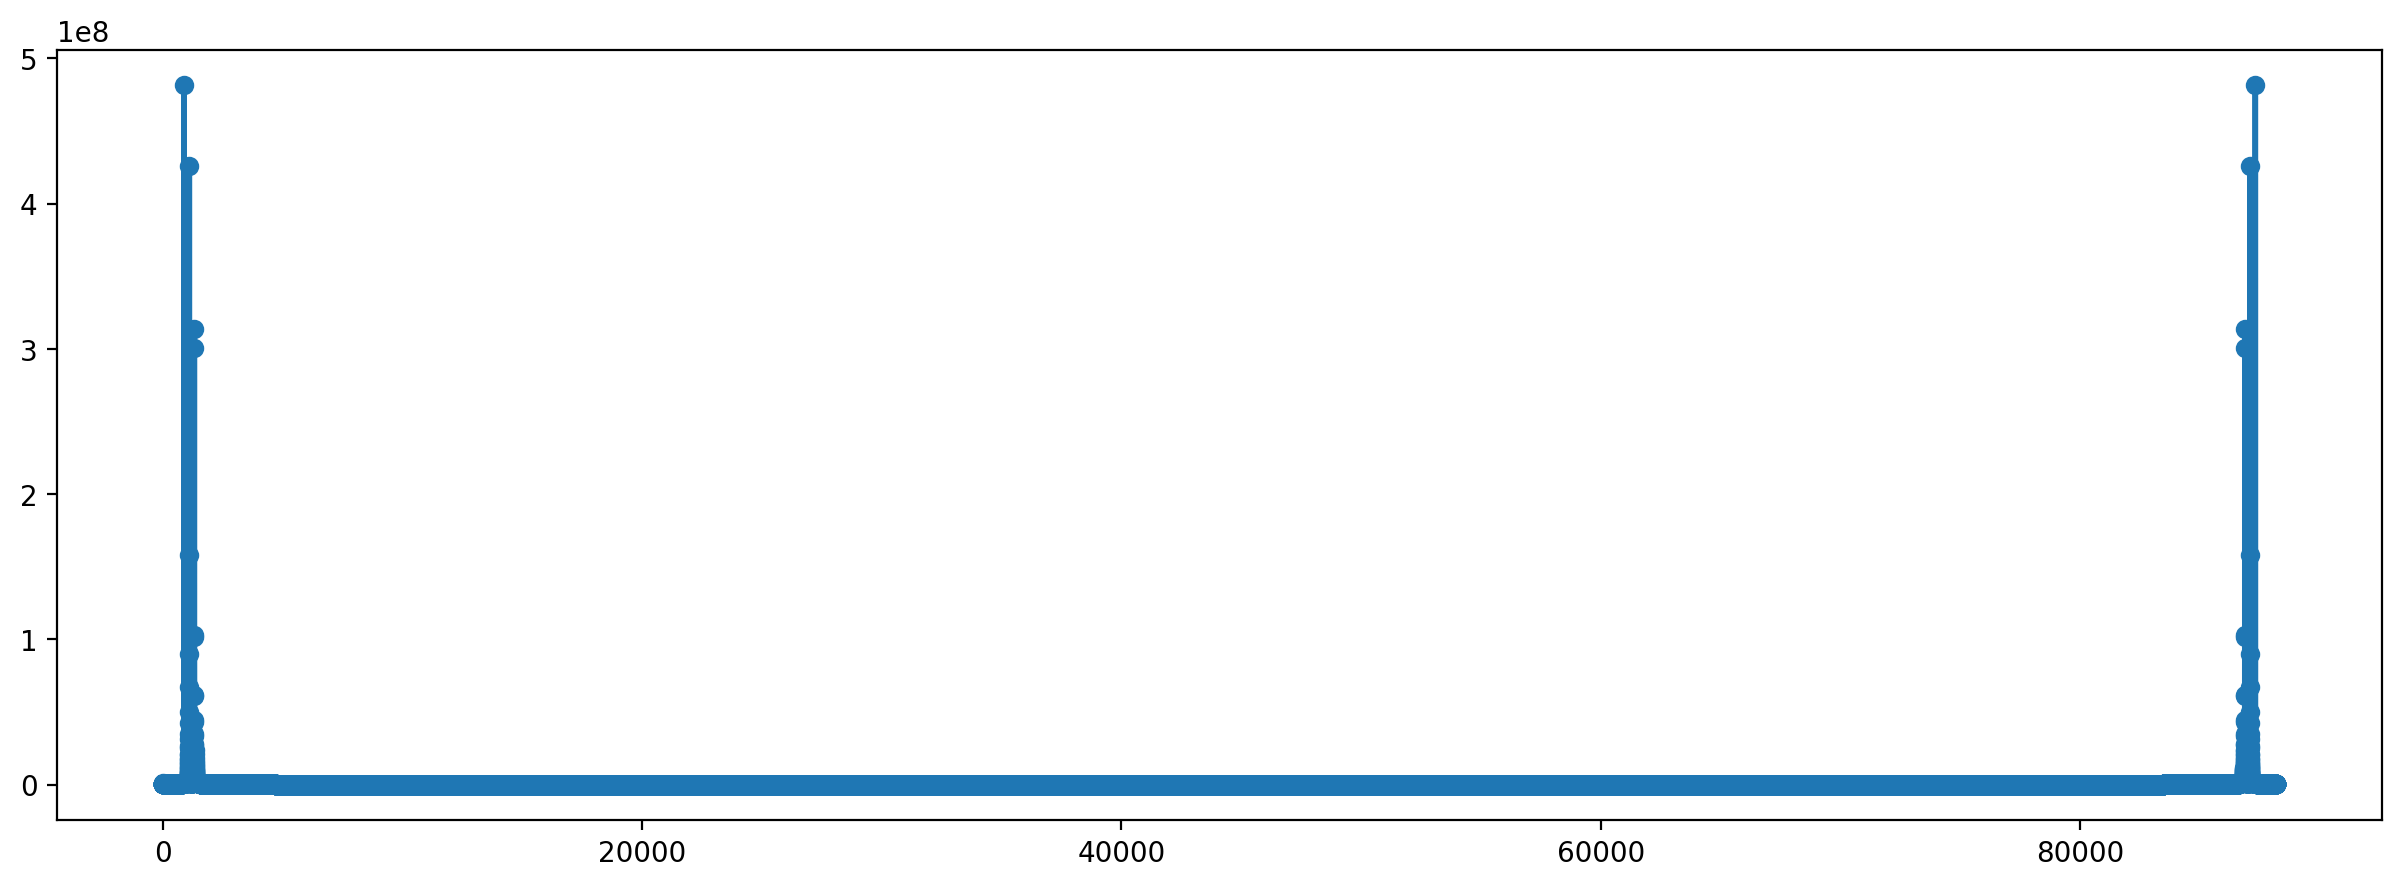

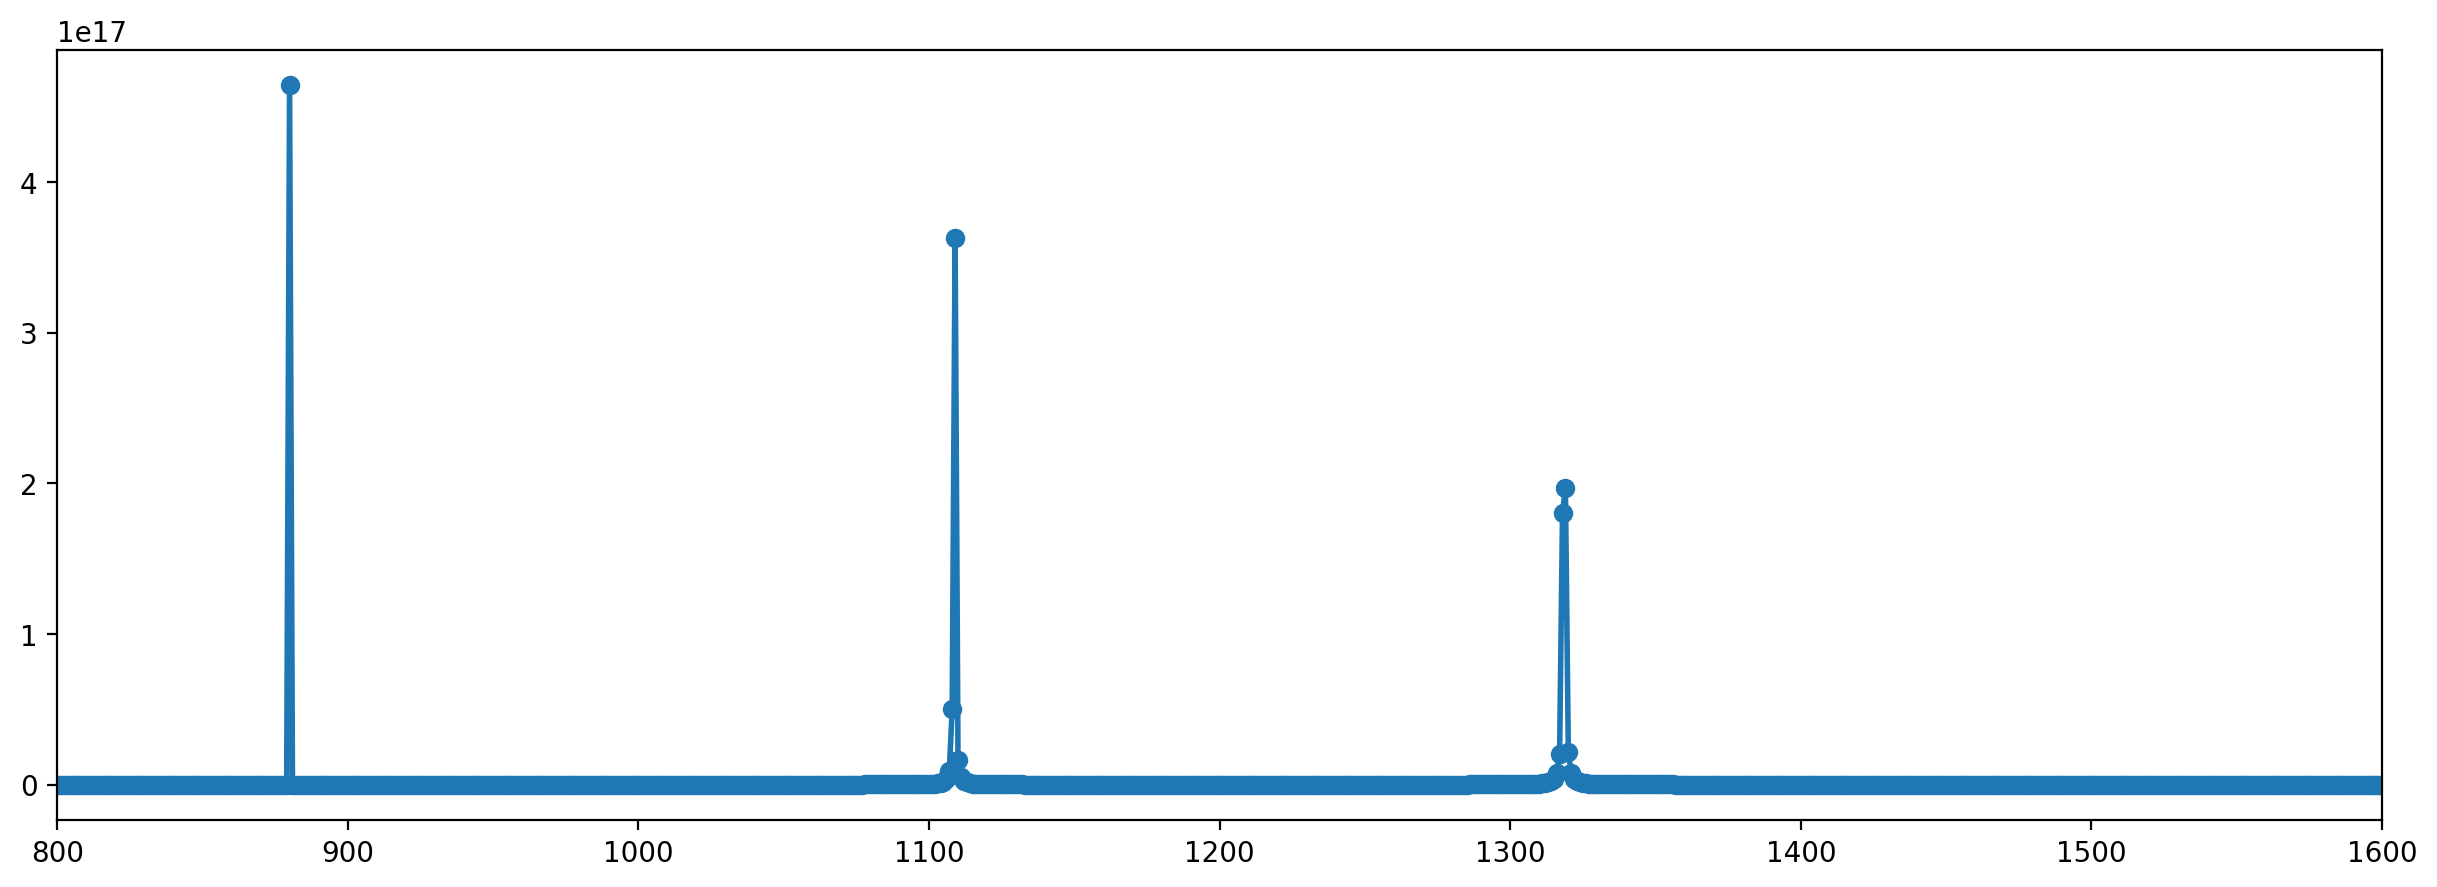

In [34]:
#For FFT, see https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.fft.html
ft = np.fft.fft(data)
print(ft)
print(ft.shape)
nn = ft.shape[0]

#plt.xlim(0,2000)
plt.plot(abs(ft),'o-',lw=2)
plt.show()

fAmp = np.zeros(nn//2)
for i in range(1,nn//2):
    fAmp[i] = abs(ft[i])**2 + abs(ft[nn-i])**2

plt.xlim(800,1600)
plt.plot(fAmp,'o-',lw=2)
plt.show()

In [35]:
#the second plot looks very similar to my two plots above, looking almost exactly like the first plot, and very similar to the second plot but with the x-axis units changed.

(9) Analyze the files "audio_file_A_SID.wav" and "audio_file_C_SID.wav" by repeating the steps above. In each case, plot the Fourier spectrum to illustrate all frequencies that are present. 


Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (44100,)
dtype: int16
min, max: -32767 32767



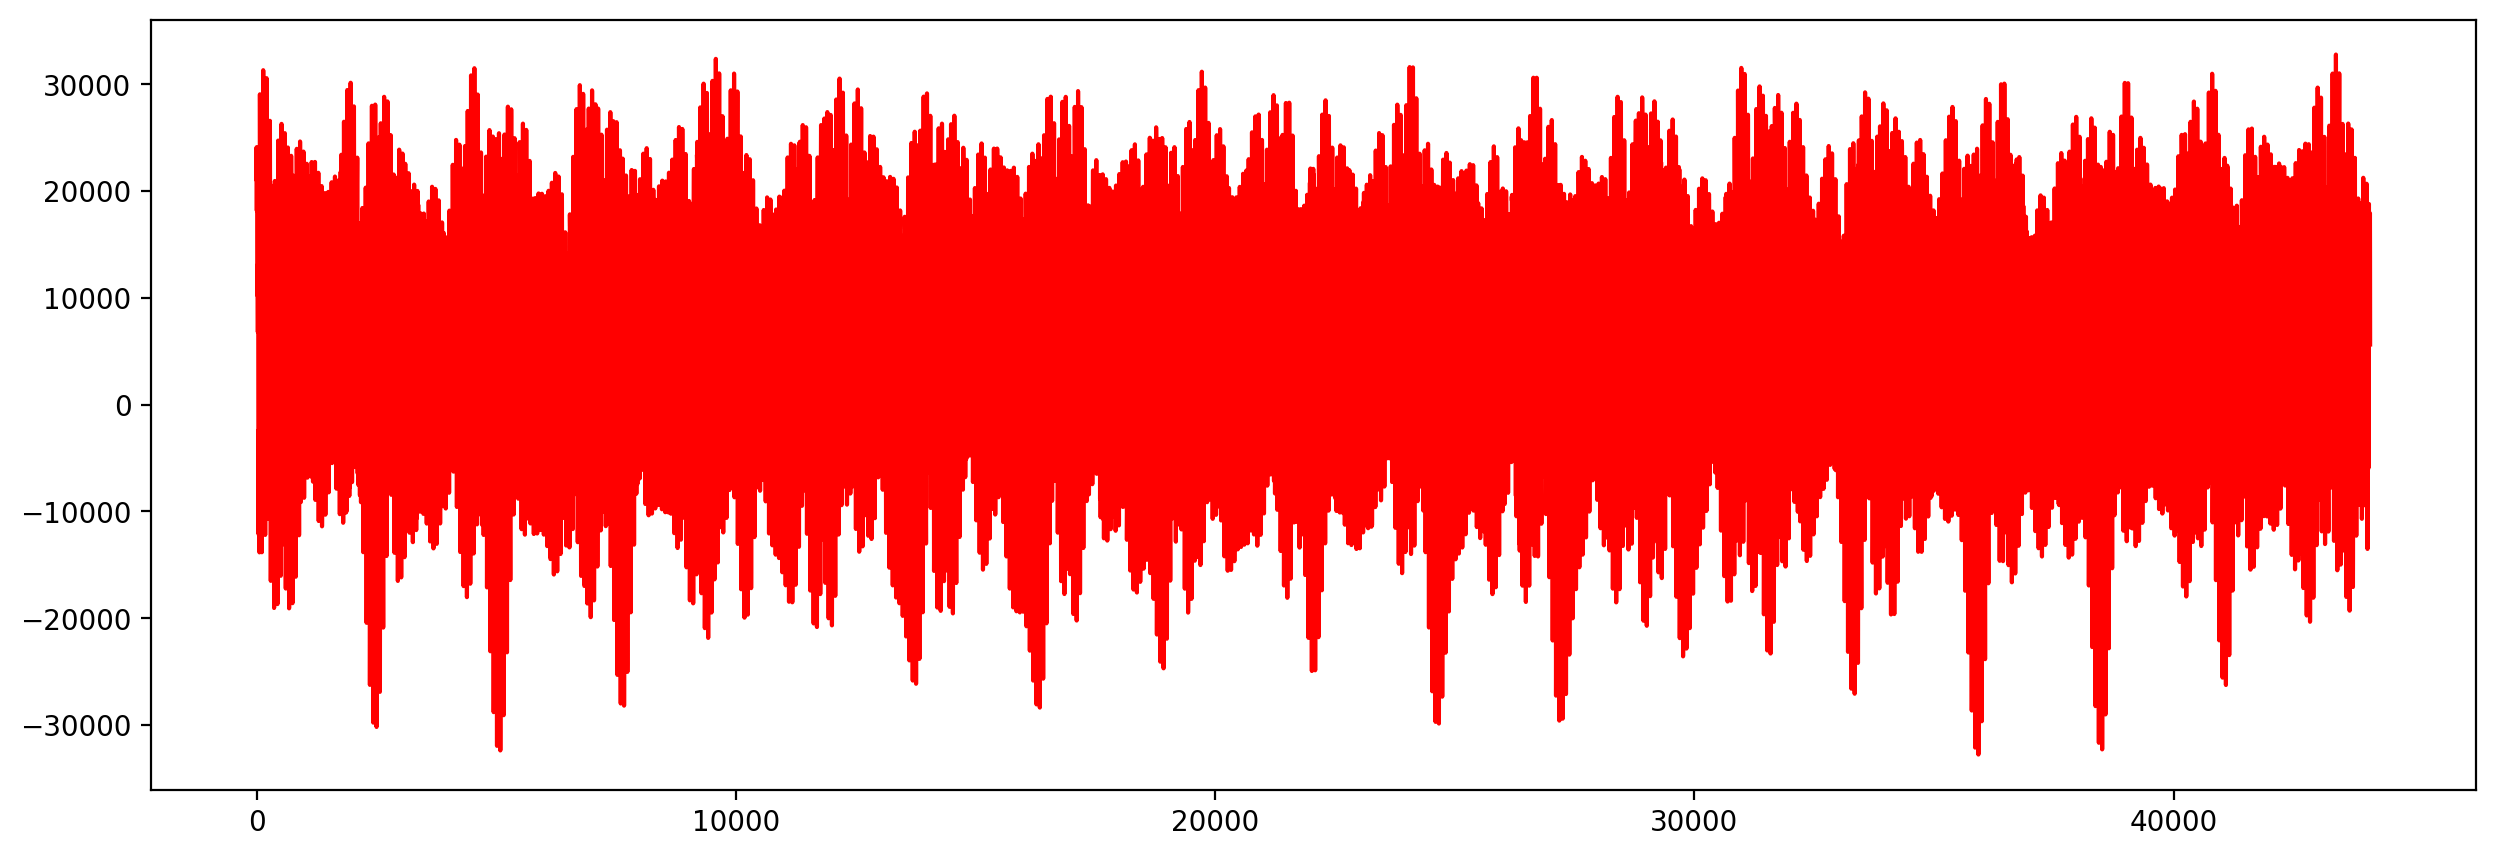

In [39]:
filename_1 = 'audio_file_A_3039281221.wav'
wave_obj = sa.WaveObject.from_wave_file(filename_1)
rate_1, data_1 = wavfile.read(filename_1)
print("Data rate [units of Hz = 1/seconds] = ",rate_1)
PrintArrayInfo(data_1,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data_1,'r-')
plt.show()

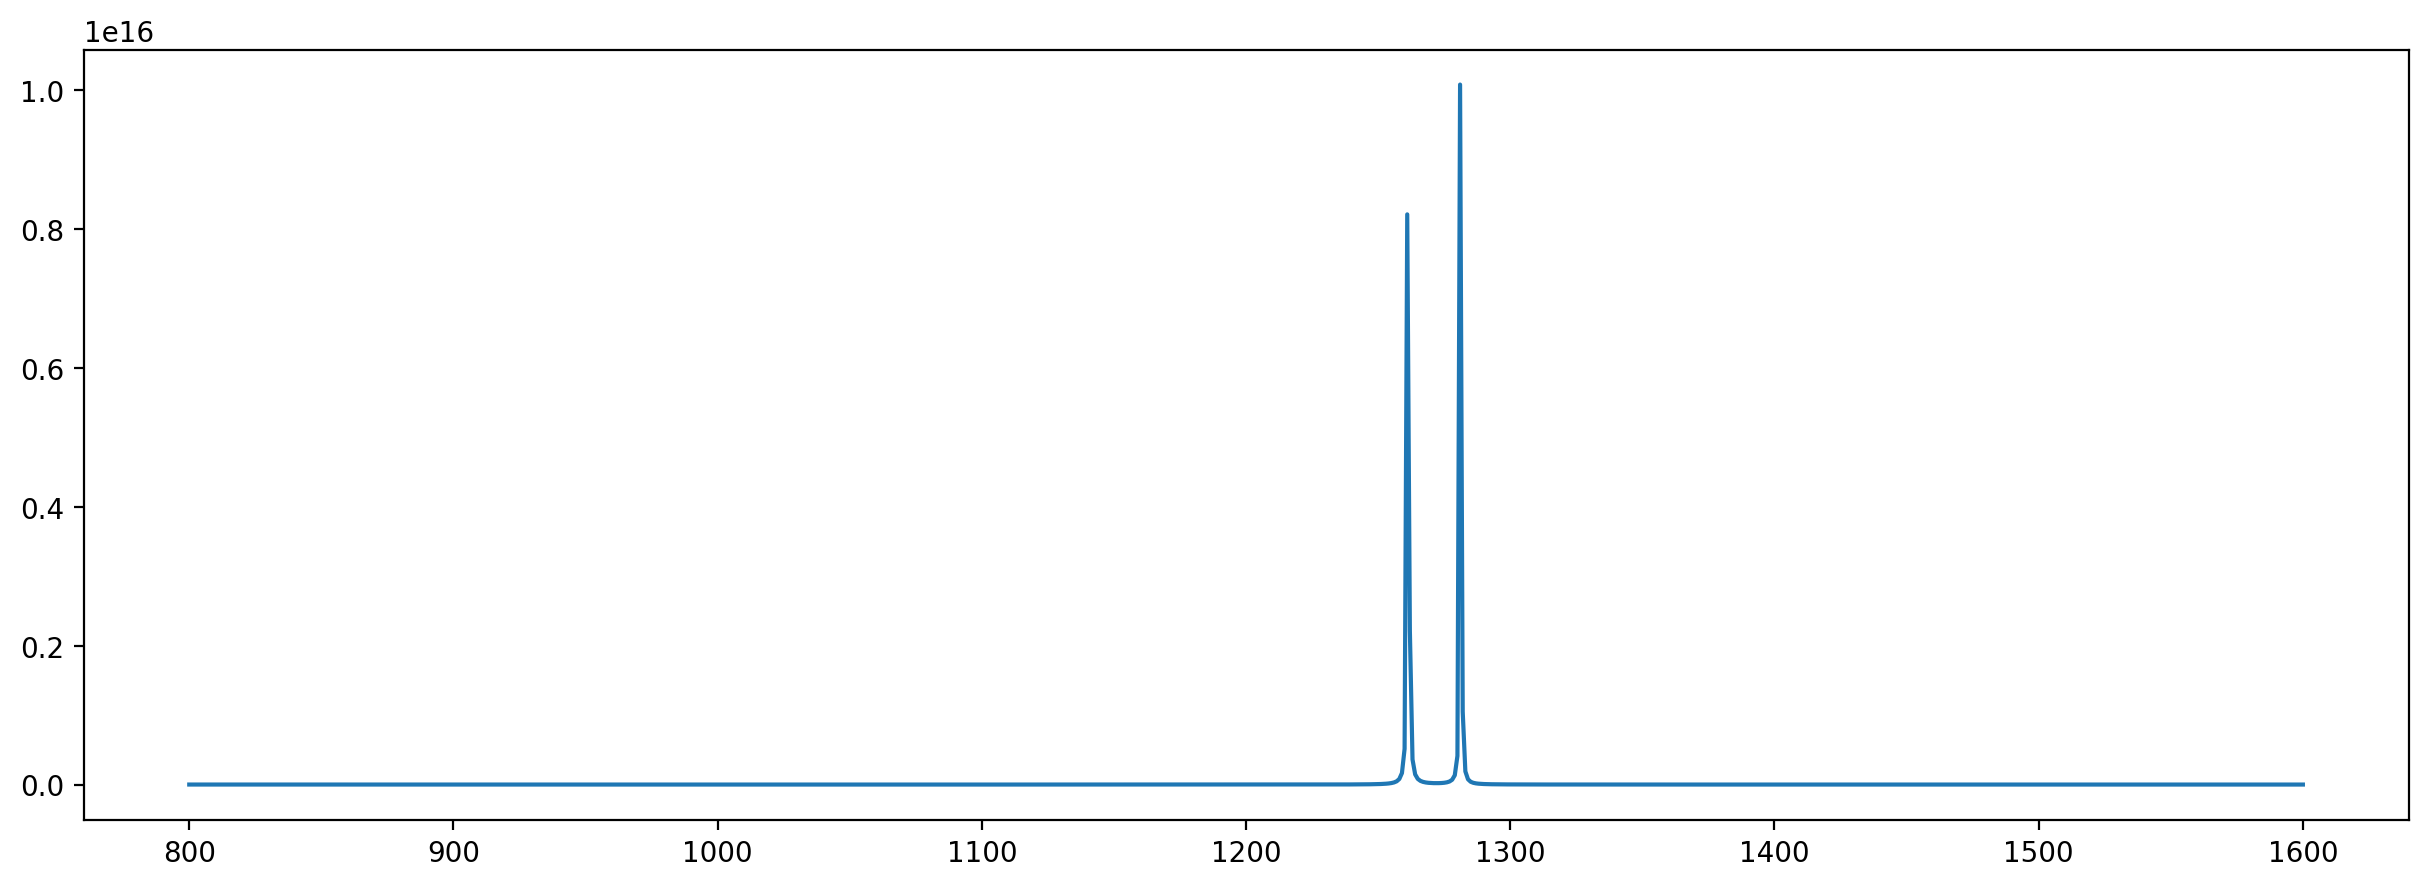

In [37]:
k1 = 800
k2 = 1600
frequency_indices = np.arange(800,1601)
frequency_indices_results = np.array([fourier(data_1,k) for k in frequency_indices])
plt.plot(frequency_indices,frequency_indices_results)


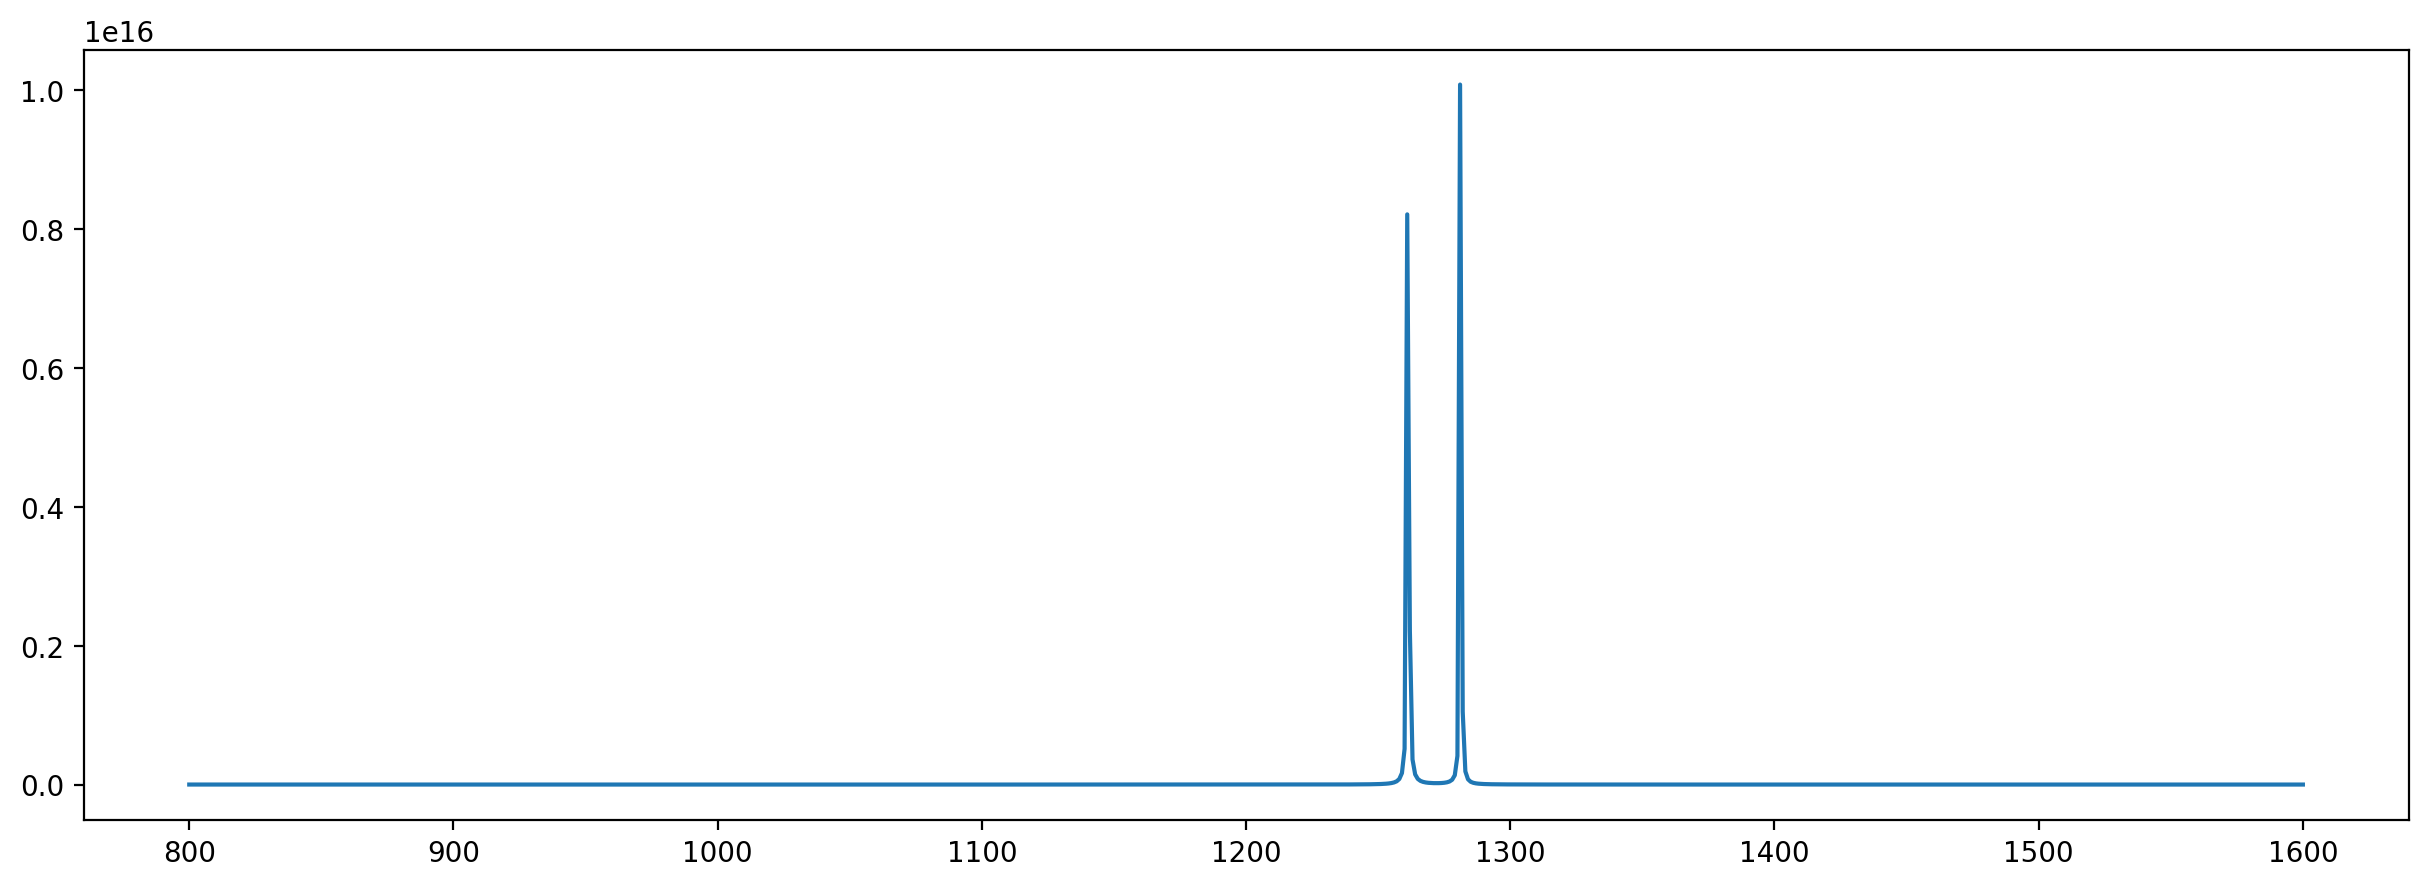

In [40]:
k1 = 800
k2 = 1600
frequency_indices = np.arange(800,1601)
frequency_hz = frequency_indices*(rate_1/len(data_1))
frequency_indices_results_hz = np.array([fourier(data_1,k) for k in frequency_indices])
plt.plot(frequency_hz,frequency_indices_results_hz)

In [41]:
peak_indices = np.argsort(frequency_indices_results_hz)[-3:]
peak_frequencies = frequency_hz[peak_indices]
print(peak_frequencies)

[1262. 1261. 1281.]


(9a) For file "audio_file_A_SID.wav" , give the frequencies in Hertz of the three waves with the largest amplitude (Excluding frequency zero.): The three frequencies are: 1) 1262 2) 1261 3) 1281

(9b) In file "audio_file_C_SID.wav", there are approximately 'N' frequencies present that are centered around frequencies 'f'. I determined N= 10 and f(Hertz)= 622.5

Data rate [units of Hz = 1/seconds] =  44100
Array: data
shape: (88200,)
dtype: int16
min, max: -32767 32767



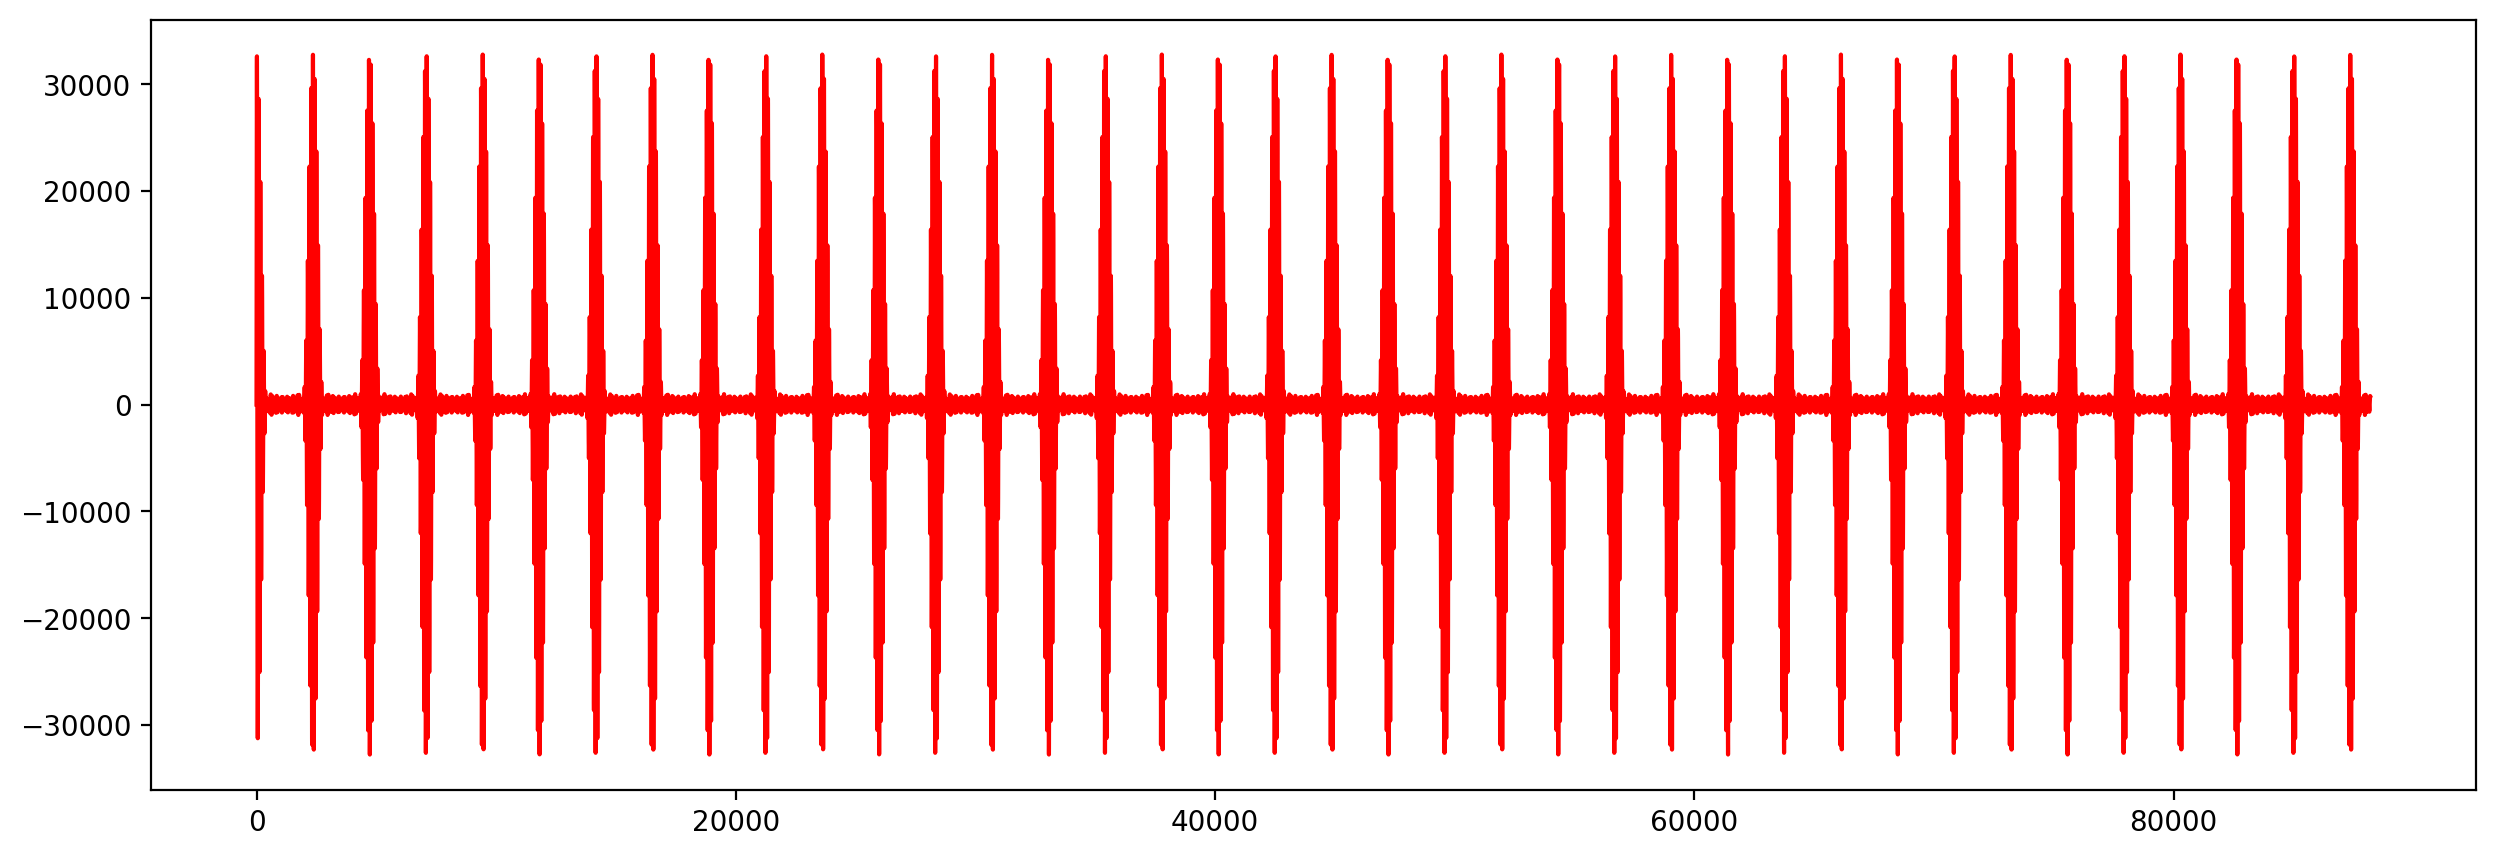

In [42]:
filename_2 = 'audio_file_C_3039281221.wav'
wave_obj = sa.WaveObject.from_wave_file(filename_2)
rate_2, data_2 = wavfile.read(filename_2)
print("Data rate [units of Hz = 1/seconds] = ",rate_2)
PrintArrayInfo(data_2,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data_2,'r-')
plt.show()

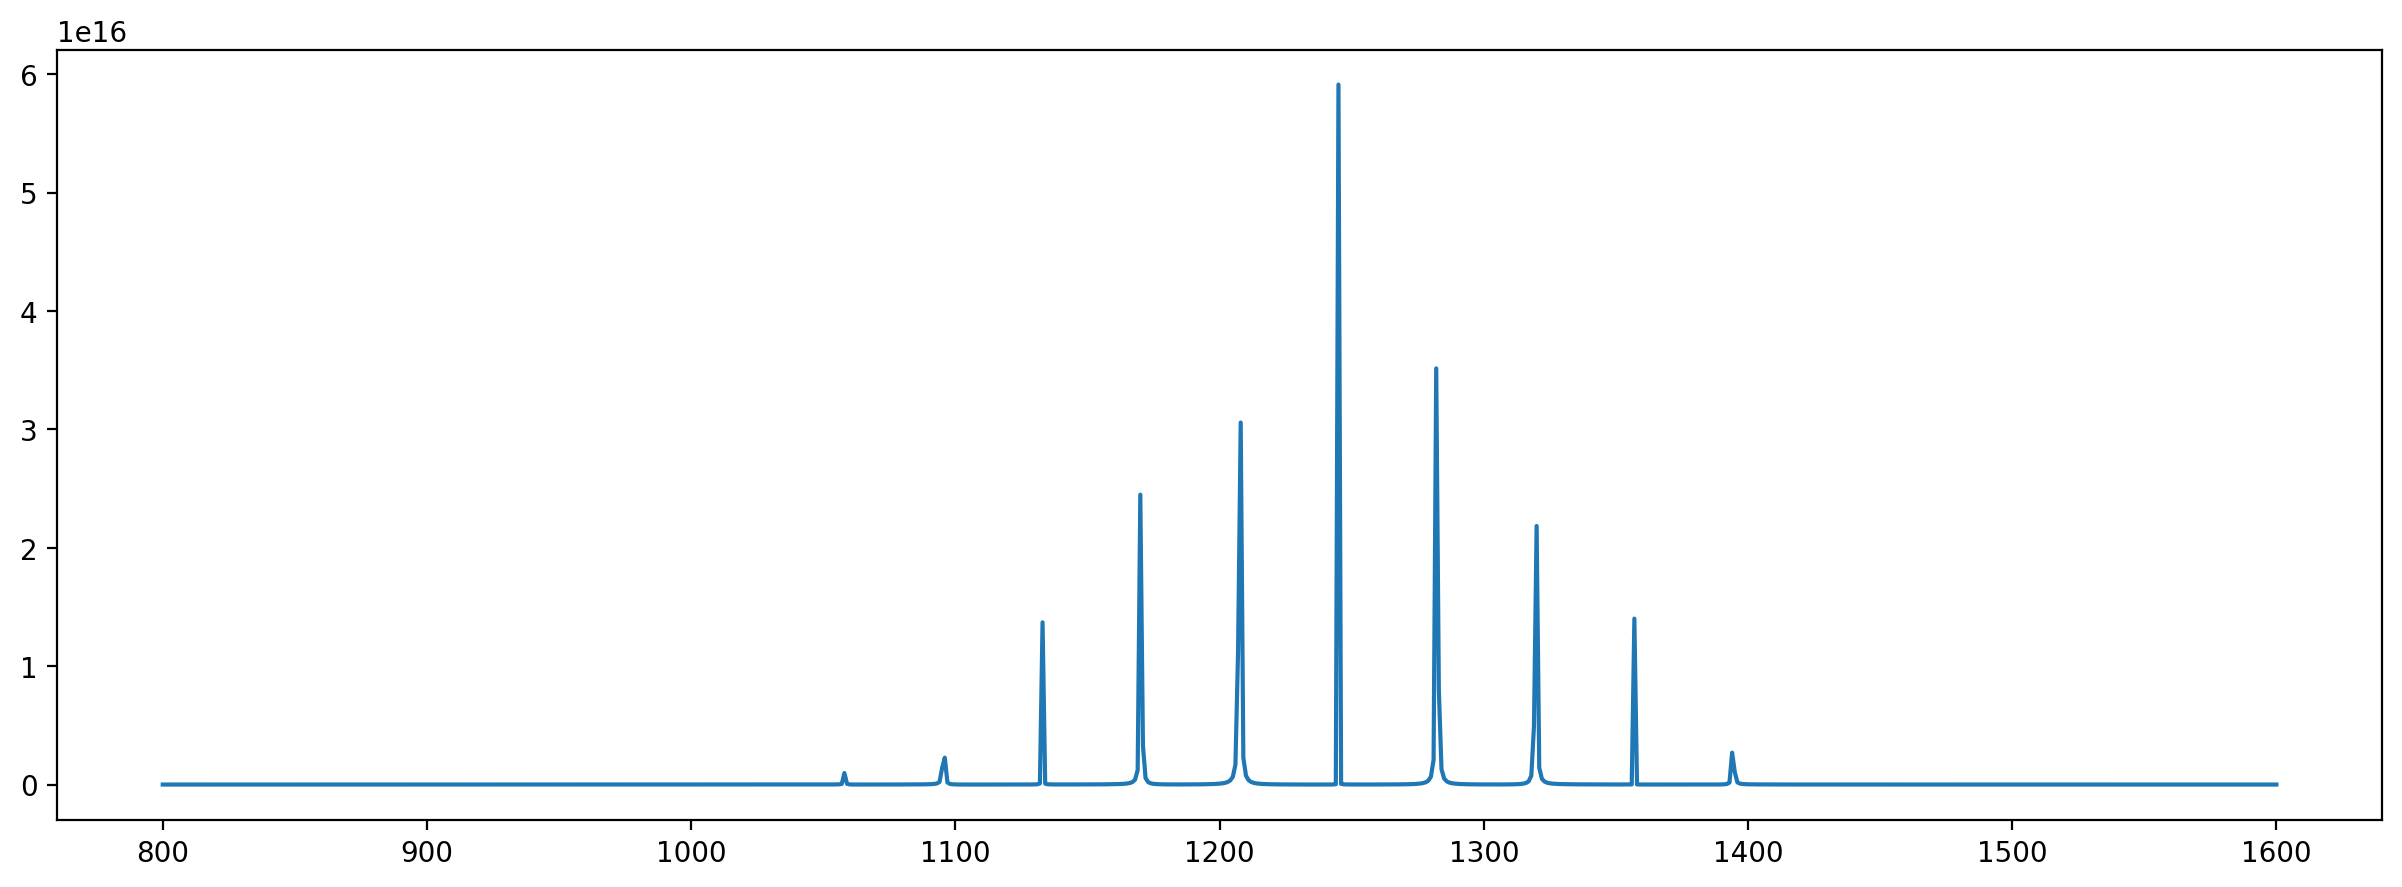

In [43]:
k1 = 800
k2 = 1600
frequency_indices = np.arange(800,1601)
frequency_indices_results = np.array([fourier(data_2,k) for k in frequency_indices])
plt.plot(frequency_indices,frequency_indices_results)


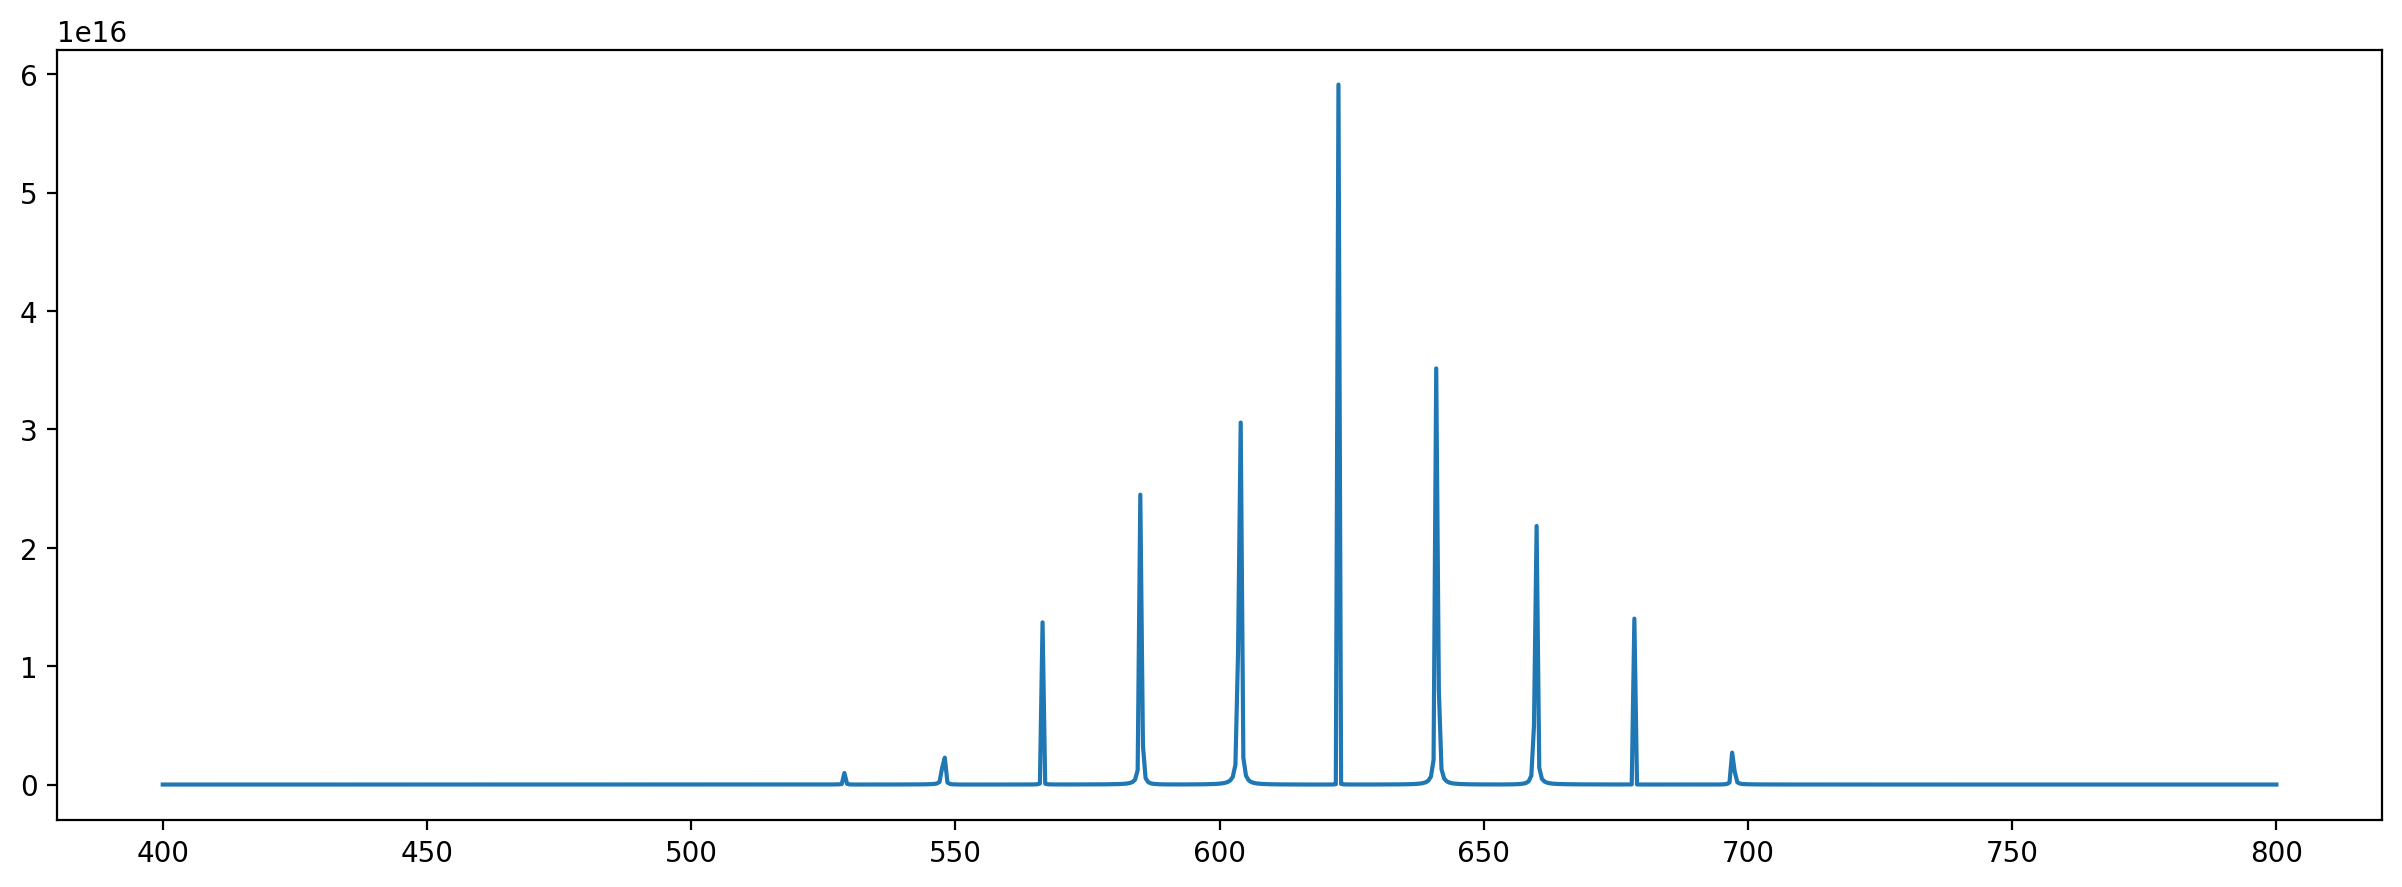

In [44]:
k1 = 800
k2 = 1600
frequency_indices = np.arange(800,1601)
frequency_hz = frequency_indices*(rate_2/len(data_2))
frequency_indices_results_hz = np.array([fourier(data_2,k) for k in frequency_indices])
plt.plot(frequency_hz,frequency_indices_results_hz)

In [46]:
peak_indices = np.argsort(frequency_indices_results_hz)[-10:]
peak_frequencies = frequency_hz[peak_indices]
print(peak_frequencies)

[659.5 641.5 603.5 566.5 678.5 660.  585.  604.  641.  622.5]
